# Activity 2 — Customer Churn Prediction

**Goal:** Predict whether a telecom customer will **churn** (leave the company) using **Logistic Regression**.

**File required:** `WA_Fn-UseC_-Telco-Customer-Churn.csv` (same folder as this notebook)

### How it works
- Logistic Regression outputs a **probability** (0–1) through the sigmoid function; probability > 0.5 is predicted as `Churn = 1`.
- Features used: `tenure`, `MonthlyCharges`, `Contract`, `InternetService`.
- Results are checked with Accuracy, Precision, Recall, F1, a confusion matrix and the ROC curve.

## Setup — imports and loading the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,8254-GNZQZ,Male,0,Yes,Yes,45,Yes,No,Fiber optic,Yes,...,Yes,Yes,No,Yes,Two year,Yes,Electronic check,89.86,4150.3,No
1,6430-FSPIB,Female,1,Yes,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,No,Month-to-month,No,Bank transfer (automatic),52.71,1862.52,No
2,6833-PUDOV,Female,0,Yes,No,47,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),22.03,1016.51,No
3,9020-YFEOM,Male,0,Yes,No,20,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Mailed check,70.06,1415.01,No
4,3108-CDITB,Male,0,No,Yes,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),24.01,47.66,No


## Task 1 — Load the dataset and preprocess (clean)

`TotalCharges` is stored as text and contains blank strings for brand-new customers, so it needs to be converted to numbers. The target `Churn` is also checked for class balance.

In [2]:
print("Shape:", df.shape)
print("\nChurn distribution:")
print(df["Churn"].value_counts())
print("\nChurn percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("\nMissing TotalCharges after conversion:", df["TotalCharges"].isna().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

Shape: (7043, 21)

Churn distribution:
Churn
No     5053
Yes    1990
Name: count, dtype: int64

Churn percentage:
Churn
No     71.74
Yes    28.26
Name: proportion, dtype: float64

Missing TotalCharges after conversion: 54


## Task 2 — Encode categorical variables

We select the four features from the lab. `Contract` and `InternetService` have unordered categories, so they are **one-hot encoded**. The target is converted to numbers: Yes = 1, No = 0.

In [3]:
features = ["tenure", "MonthlyCharges", "Contract", "InternetService"]

X = df[features].copy()
y = df["Churn"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(X, columns=["Contract", "InternetService"], drop_first=True, dtype=int)
X.head()

,tenure,MonthlyCharges,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No
0,45,89.86,0,1,1,0
1,35,52.71,0,0,0,0
2,47,22.03,0,1,0,1
3,20,70.06,0,1,0,0
4,2,24.01,0,0,0,1


## Task 3 — Split and scale the data

`stratify=y` keeps the churn / no-churn ratio the same in the training and test sets. The scaler is fitted on the training data only.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)

Train: (5634, 6)  Test: (1409, 6)


## Task 4 — Train the Logistic Regression model

`predict()` gives the class (0/1) and `predict_proba()` gives the churn probability, which is needed for the ROC curve later.

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(pd.Series(model.coef_[0], index=X.columns).round(3))

tenure                        -0.832
MonthlyCharges                 0.530
Contract_One year             -0.438
Contract_Two year             -0.999
InternetService_Fiber optic    0.227
InternetService_No             0.099
dtype: float64


## Task 5 — Evaluate: Accuracy, Precision, Recall, F1-score

- **Accuracy** – share of all predictions that are correct.
- **Precision** – of the customers predicted to churn, how many really did.
- **Recall** – of the customers who really churned, how many we caught.
- **F1** – balance between precision and recall.

Because most customers do not churn, accuracy alone can look good even when many churners are missed, so recall and F1 matter here.

In [6]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Accuracy  : 0.7970
Precision : 0.6905
Recall    : 0.5101
F1-score  : 0.5867

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1011
       Churn       0.69      0.51      0.59       398

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## Task 6 — Plot the Confusion Matrix

Rows are the true classes, columns are the predicted classes. The diagonal shows correct predictions; the off-diagonal cells are mistakes (false positives and false negatives).

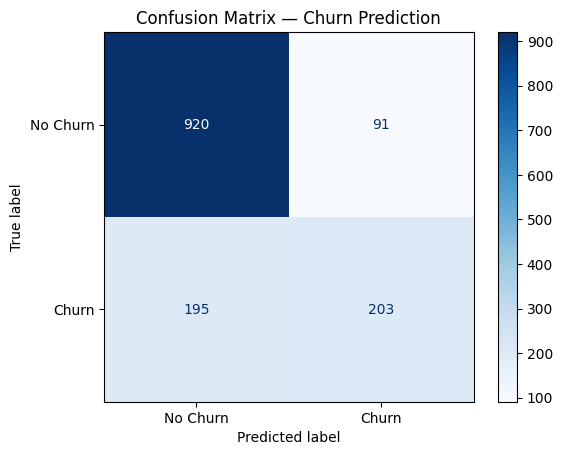

True Negatives: 920, False Positives: 91, False Negatives: 195, True Positives: 203


In [7]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Churn Prediction")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}")

## Task 7 — Plot the ROC Curve

The ROC curve shows the true-positive rate against the false-positive rate for every possible probability threshold. **AUC** is the area under it: 0.5 = random guessing, 1.0 = perfect.

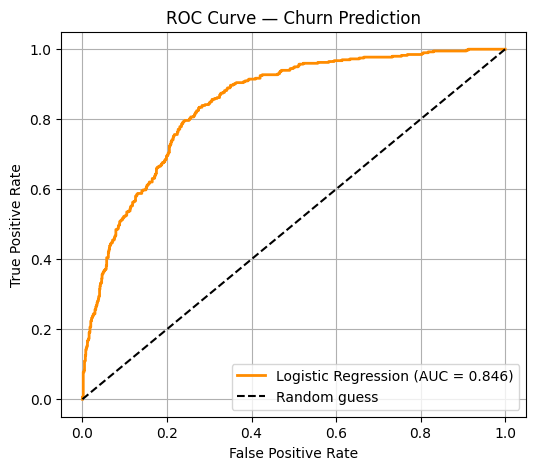

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Churn Prediction")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Interpretation
- Customers on **month-to-month** contracts and with **short tenure** are the most likely to churn; long contracts and long tenure lower the churn probability.
- The model separates churners from non-churners clearly better than random guessing (AUC well above 0.5).
- Recall (about 0.51) is lower than precision (about 0.69): the model misses roughly half of the real churners because they are the minority class. Using `class_weight="balanced"` or lowering the 0.5 threshold would catch more churners at the cost of more false alarms.